# 📝 Text Summarization Fine-Tuning with FLAN-T5 (Encoder-Decoder, 2026 Standards)

**Complete Classroom Implementation**

> **Intended runtime**: Google Colab with GPU — go to **Runtime → Change runtime type → T4 GPU** before running.

In this notebook, you'll learn how to fine-tune a pre-trained **FLAN-T5 model** — a full **encoder-decoder** transformer — for text summarization using the Hugging Face Transformers library.

## What You'll Learn:
1. ✅ Load and explore a large real-world summarization dataset (CNN/DailyMail)
2. ✅ Tokenize text for encoder-decoder models (`text_target`, label masking — no GPT-style fixes needed!)
3. ✅ Understand why seq2seq needs `Seq2SeqTrainer` + generation-based metrics (ROUGE)
4. ✅ Fine-tune FLAN-T5-large and evaluate with ROUGE scores
5. ✅ Generate summaries with `model.generate()` (beam search decoding)

## Task:
**Abstractive Text Summarization** — read a full news article and write a short, fluent summary of its highlights.

## ⚠️ This notebook completes the trilogy!
All three notebooks follow the **same phase structure** so you can directly compare:
- **BERT** on tweet sentiment (encoder, ~66M params) → `Distill_BERT_Finetuning.ipynb`
- **GPT** on news classification (decoder, ~82M params) → `GPT_News_Classification_FineTuning_Colab.ipynb`
- **FLAN-T5** on summarization (encoder-decoder, ~780M params) ← **you are here**

---
**Prerequisites**: The BERT and GPT notebooks (or equivalent familiarity with the Transformers library).


## 📦 Phase 1: Environment Setup

First, let's install the required packages. These are the **2026 standard versions** of the libraries.


In [1]:
# ============================================================
# Package Installation with UV (2026 standard)
# ============================================================
# Works in Google Colab (--system) and in a local uv venv.
# Locally you can also run: uv pip install <packages> in your terminal.
import sys
import subprocess

IS_COLAB = "google.colab" in sys.modules

def uv_install(*packages):
    """Install packages with uv (adds --system automatically in Colab)."""
    cmd = ["uv", "pip", "install"] + (["--system"] if IS_COLAB else []) + list(packages)
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)

uv_install(
    "transformers",   # 5.x — latest
    "datasets",       # 5.x — latest
    "evaluate",
    "accelerate",
    "sentencepiece",  # required by the T5 tokenizer
    "protobuf",       # required by sentencepiece
    "rouge-score",    # ROUGE evaluation metric for summarization
    "nltk",           # sentence splitting for ROUGE post-processing
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "pandas",
    "numpy",
    # "torch",        # uncomment locally if torch is missing (Colab ships it)
)
print("✅ All packages installed successfully!")


uv pip install transformers datasets evaluate accelerate sentencepiece protobuf rouge-score nltk matplotlib seaborn scikit-learn pandas numpy


Using Python 3.12.11 environment at: /home/zeus/miniconda3/envs/cloudspace
Resolved 92 packages in 1.83s
   Building rouge-score==0.1.2
 Downloaded sentencepiece
 Downloaded nltk
      Built rouge-score==0.1.2
Prepared 3 packages in 393ms


✅ All packages installed successfully!


Installed 3 packages in 76ms
 + nltk==3.10.3
 + rouge-score==0.1.2
 + sentencepiece==0.2.2


In [2]:
# ============================================================
# Library Import Verification - FIXED
# ============================================================

import sys

def check_import(library_name, version_attr="__version__"):  # ✅ Removed unused import_statement
    try:
        module = __import__(library_name)
        version = getattr(module, version_attr, "version unknown")
        print(f"✅ {library_name:<20} version: {version}")
        return True
    except ImportError as e:
        print(f"❌ {library_name:<20} FAILED - {e}")
        return False

print("=" * 55)
print("       Library Import Verification Check")
print("=" * 55)
print(f"Python version: {sys.version}\n")

results = {}

# --- Core Libraries ---
print("📦 Core Libraries:")
results["transformers"]   = check_import("transformers")
results["datasets"]       = check_import("datasets")
results["evaluate"]       = check_import("evaluate")
results["accelerate"]     = check_import("accelerate")

# --- Seq2Seq ---
print("\n📋 Seq2Seq:")
results["sentencepiece"]  = check_import("sentencepiece")

# --- Metrics ---
print("\n📈 Metrics:")
try:
    import rouge_score
    print(f"✅ {'rouge_score':<20} imported successfully")
    results["rouge_score"] = True
except ImportError as e:
    print(f"❌ {'rouge_score':<20} FAILED - {e}")
    results["rouge_score"] = False

# --- Visualization ---
print("\n🎨 Visualization:")
results["matplotlib"]     = check_import("matplotlib")
results["seaborn"]        = check_import("seaborn")

# --- Data & ML ---
print("\n🔢 Data & ML:")
results["sklearn"]        = check_import("sklearn")
results["pandas"]         = check_import("pandas")
results["numpy"]          = check_import("numpy")

# --- Deep Learning ---
print("\n🤖 Deep Learning:")
try:
    import torch
    print(f"✅ {'torch':<20} version: {torch.__version__}")
    print(f"   CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
    results["torch"] = True
except ImportError as e:
    print(f"❌ {'torch':<20} FAILED - {e}")
    results["torch"] = False

# --- Summary ---
print("\n" + "=" * 55)
passed = sum(results.values())
total  = len(results)

if passed == total:
    print(f"✅ All {total}/{total} libraries imported successfully!")
else:
    print(f"⚠️  {passed}/{total} libraries passed")
    failed = [lib for lib, ok in results.items() if not ok]
    print(f"❌ Failed libraries: {', '.join(failed)}")
    print("\n💡 Fix failed installs with:")
    for lib in failed:
        print(f"   !uv pip install {lib}")

print("=" * 55)


       Library Import Verification Check
Python version: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:09:17) [GCC 11.2.0]

📦 Core Libraries:


✅ transformers         version: 5.17.0
✅ datasets             version: 5.0.1
✅ evaluate             version: 0.4.6
✅ accelerate           version: 1.15.0

📋 Seq2Seq:
✅ sentencepiece        version: 0.2.2

📈 Metrics:
✅ rouge_score          imported successfully

🎨 Visualization:
✅ matplotlib           version: 3.8.2
✅ seaborn              version: 0.13.2

🔢 Data & ML:
✅ sklearn              version: 1.3.2
✅ pandas               version: 2.1.4
✅ numpy                version: 1.26.4

🤖 Deep Learning:
✅ torch                version: 2.8.0+cu128
   CUDA available: True
   GPU: Tesla T4

✅ All 12/12 libraries imported successfully!


In [3]:
!pip install evaluate

### GPU Check

Let's check if we have a GPU available. Training FLAN-T5-large is **much faster** with GPU!
> Go to **Runtime → Change runtime type → T4 GPU** if you don't see GPU below.


In [4]:
# ============================================================
# Device Selection — Colab GPU (CUDA) or Apple Silicon (MPS)
# ============================================================
import torch

FORCE_DEVICE = "cuda"   # None = auto | "cuda" = Colab GPU | "mps" = Apple Silicon | "cpu" = no GPU

def pick_device():
    if FORCE_DEVICE:
        return torch.device(FORCE_DEVICE)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = pick_device()

print("=" * 60)
print("DEVICE CONFIGURATION")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available:  {torch.backends.mps.is_available()}")

if device.type == "cuda":
    print(f"\n✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"   BF16 supported: {torch.cuda.is_bf16_supported()}")
elif device.type == "mps":
    print("\n✅ Apple Silicon GPU detected — using MPS acceleration")
else:
    print("\n⚠️ No GPU detected. Training will run on CPU (slower).")
    print("   Colab: Runtime > Change runtime type > T4 GPU")

print(f"\n📍 Using device: {device}")
print("=" * 60)


DEVICE CONFIGURATION
PyTorch version: 2.8.0+cu128
CUDA available: True
MPS available:  False

✅ GPU detected: Tesla T4
   GPU memory: 15.64 GB
   BF16 supported: True

📍 Using device: cuda


### Import Libraries


In [5]:
# Core libraries
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hugging Face libraries
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
from datasets import load_dataset, DatasetDict
import evaluate

# Sentence splitting (ROUGE post-processing)
import nltk
from nltk.tokenize import sent_tokenize

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


### Configuration


In [6]:
# Model configuration
MODEL_NAME = "google/flan-t5-large"  # ~780M params, fits Colab T4 (bf16) and Apple Silicon (MPS)
# MODEL_NAME = "google/flan-t5-base"  # ~250M params, faster alternative if memory is tight

# Dataset configuration
DATASET_NAME   = "abisee/cnn_dailymail"   # canonical summarization benchmark
DATASET_CONFIG = "3.0.0"

# Sub-sample sizes (full CNN/DailyMail has 287K articles — far too big for a classroom demo)
TRAIN_SIZE = 3000
VAL_SIZE   = 400
TEST_SIZE  = 300

# Sequence lengths
MAX_SOURCE_LENGTH = 512   # articles are long — we truncate to 512 tokens
MAX_TARGET_LENGTH = 128   # highlights are short summaries

# Training hyperparameters
LEARNING_RATE = 2e-5      # standard fine-tuning LR (higher values like 1e-4 are also common for T5,
                          # but we keep 2e-5 for consistency with the BERT and GPT notebooks)
BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8   # effective batch size = 2 × 8 = 16
NUM_EPOCHS = 2
SEED = 42

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Model: {MODEL_NAME}")
print(f"Dataset: {DATASET_NAME} (config {DATASET_CONFIG})")
print(f"Train/Val/Test: {TRAIN_SIZE} / {VAL_SIZE} / {TEST_SIZE}")
print(f"Max source length: {MAX_SOURCE_LENGTH} tokens")
print(f"Max target length: {MAX_TARGET_LENGTH} tokens")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE} (× {GRADIENT_ACCUMULATION_STEPS} grad accum = {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS} effective)")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Seed: {SEED}")
print("=" * 60)

# Set random seeds for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)


CONFIGURATION
Model: google/flan-t5-large
Dataset: abisee/cnn_dailymail (config 3.0.0)
Train/Val/Test: 3000 / 400 / 300
Max source length: 512 tokens
Max target length: 128 tokens
Learning rate: 2e-05
Batch size: 2 (× 8 grad accum = 16 effective)
Epochs: 2
Seed: 42


## 📊 Phase 2: Data Loading and Exploration

**CNN/DailyMail** is the canonical benchmark for abstractive summarization:
- **~287,000** news articles from CNN and the Daily Mail
- Each article comes with **human-written highlights** (bulleted summaries) that serve as our reference summaries
- Articles are long (hundreds of words); highlights are short (a few sentences)

We'll sub-sample it heavily so the classroom training run finishes in minutes, not hours.


### Load Dataset

> **Why the `revision="refs/convert/parquet"` argument?**
> `datasets` 5.x **dropped support for loading scripts** (the old `cnn_dailymail.py` script no longer runs).
> The Hugging Face Hub hosts an **official parquet export** of the exact same data at the git ref
> `refs/convert/parquet` — so we load that instead. Same rows, same columns, modern loader.


In [7]:
print("Loading CNN/DailyMail dataset (parquet export)...")
raw_dataset = load_dataset(
    DATASET_NAME,
    revision="refs/convert/parquet",
    data_dir=DATASET_CONFIG,  # e.g. "3.0.0" — config folder in the parquet export
)

print("\n✅ Dataset loaded!")
print("\nFull dataset structure:")
print(raw_dataset)


Loading CNN/DailyMail dataset (parquet export)...


3.0.0/train/0000.parquet: reconstructing file:   0%|          |  0.00B /  257MB            

3.0.0/train/0000.parquet: downloading bytes:           |  0.00B            

3.0.0/train/0001.parquet: reconstructing file:   0%|          |  0.00B /  257MB            

3.0.0/train/0001.parquet: downloading bytes:           |  0.00B            

...

3.0.0/test/0000.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]


✅ Dataset loaded!

Full dataset structure:
DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})


### Create Sub-Sampled Splits

Unlike the GPT notebook, we do **not** need balanced sampling here — there are no classes!
We simply shuffle each split with our seed and take the first N examples. This keeps the
notebook fast while staying representative of the real data distribution.


In [8]:
# Shuffle each split with a fixed seed, then sub-sample
train_data = raw_dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
val_data   = raw_dataset["validation"].shuffle(seed=SEED).select(range(VAL_SIZE))
test_data  = raw_dataset["test"].shuffle(seed=SEED).select(range(TEST_SIZE))

dataset = DatasetDict({
    "train":      train_data,
    "validation": val_data,
    "test":       test_data
})

print("✅ Sub-sampled splits created!")
print(f"\nDataset sizes:")
print(f"  Training set:   {len(dataset['train'])} samples")
print(f"  Validation set: {len(dataset['validation'])} samples")
print(f"  Test set:       {len(dataset['test'])} samples")


✅ Sub-sampled splits created!

Dataset sizes:
  Training set:   3000 samples
  Validation set: 400 samples
  Test set:       300 samples


### Explore Dataset


In [9]:
# Split sizes
print("Split Sizes:")
print("-" * 40)
for split, data in dataset.items():
    print(f"  {split:<12}: {len(data):>5} samples")

# Word-count statistics on the training split
train_df = dataset["train"].to_pandas()
train_df["article_words"]    = train_df["article"].str.split().str.len()
train_df["highlights_words"] = train_df["highlights"].str.split().str.len()

print(f"\nWord-count statistics (Training Set):")
print("-" * 55)
print(f"{'':>18}{'mean':>8}{'median':>8}{'max':>8}")
print(f"{'articles':>18}{train_df['article_words'].mean():>8.0f}"
      f"{train_df['article_words'].median():>8.0f}{train_df['article_words'].max():>8}")
print(f"{'highlights':>18}{train_df['highlights_words'].mean():>8.0f}"
      f"{train_df['highlights_words'].median():>8.0f}{train_df['highlights_words'].max():>8}")

print(f"\n💡 Articles average ~{train_df['article_words'].mean():.0f} words — that's why we truncate")
print(f"   sources to {MAX_SOURCE_LENGTH} tokens and targets to {MAX_TARGET_LENGTH} tokens.")


Split Sizes:
----------------------------------------
  train       :  3000 samples
  validation  :   400 samples
  test        :   300 samples



Word-count statistics (Training Set):
-------------------------------------------------------
                      mean  median     max
          articles     685     628    1900
        highlights      51      48     362

💡 Articles average ~685 words — that's why we truncate
   sources to 512 tokens and targets to 128 tokens.


### View a Sample Article


In [10]:
sample = dataset["train"][0]

print("SAMPLE ARTICLE:")
print("=" * 80)
print(sample["article"][:1200])
if len(sample["article"]) > 1200:
    print(f"... [article truncated for display, {len(sample['article'])} chars total]")

print("\n" + "=" * 80)
print("REFERENCE HIGHLIGHTS (what a human wrote):")
print("=" * 80)
print(sample["highlights"])


SAMPLE ARTICLE:
By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poisoning would have been unconscious 'within minutes', investigators said today. The bodies of married couple John and Audrey Cook were discovered alongside their daughter, Maureen, at the mobile home they shared on Tremarle Home Park in Camborne, west Cornwall. The inquests have now opened into the deaths last Saturday, with investigators saying the three died along with the family's pet dog, of carbon monoxide poisoning from a cooker. Tragic: The inquests have opened into the deaths of three members of the same family who were found in their static caravan last weekend. John and Audrey Cook are pictured . Awful: The family died following carbon monoxide poisoning at this caravan at the Tremarle Home Park in Camborne, Cornwall . It is also believed there was no working carbon monoxide det

## 🔤 Phase 3: Tokenization

This is where encoder-decoder models **differ from both BERT and GPT**. Pay close attention!


### Encoder-Decoder Tokenization: What's Different?

| Aspect | BERT (encoder) | GPT (decoder) | T5 (encoder-decoder) |
|--------|----------------|---------------|----------------------|
| **What gets tokenized** | Input only | Input only (labels = shifted input) | **Source AND target, separately** |
| **How targets are passed** | A single `label` class id | `input_ids` shifted internally | `text_target=` argument → becomes `labels` |
| **`token_type_ids`** | ✅ Yes | ❌ No | ❌ No |
| **Pad token** | Built-in `[PAD]` | ❌ None — had to borrow `eos` | ✅ Native `<pad>` — **no fixes needed!** |
| **Padding strategy** | Right (static, `max_length`) | Left (static, `max_length`) | **Dynamic** via the collator |
| **Label masking** | Not applicable | Handled internally | Collator pads labels with **-100** (ignored by loss) |

> **Key insight**: a seq2seq model learns `p(target | source)`. The **encoder** reads the source
> article; the **decoder** generates the target summary one token at a time. During training the
> decoder sees the *teacher-forced* target and the model shifts the labels internally to compute
> next-token loss — you just hand it `labels`.


### Load Tokenizer

Notice: T5 has a **native pad token** — no `pad_token = eos_token` hack like GPT needed!


In [11]:
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"\nTokenizer loaded!")
print(f"  Vocabulary size: {tokenizer.vocab_size:,}")
print(f"  EOS token:       '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")
print(f"  PAD token:       '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})  ✅ built-in, no fix needed!")


Loading tokenizer: google/flan-t5-large


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]


Tokenizer loaded!
  Vocabulary size: 32,100
  EOS token:       '</s>' (id=1)
  PAD token:       '<pad>' (id=0)  ✅ built-in, no fix needed!


### FLAN Task Prefix

**FLAN** models are instruction-tuned: they expect every input to start with a **task prefix**
telling them what to do. For summarization the convention is:

```
"summarize: " + article
```

Without the prefix, FLAN-T5's quality drops noticeably — the model was trained that way.


In [12]:
PREFIX = "summarize: "

def preprocess_function(examples):
    """
    Tokenize source articles AND target highlights separately.

    - Source → input_ids + attention_mask (max MAX_SOURCE_LENGTH, truncated)
    - Target → tokenized via `text_target=`, stored as `labels` (max MAX_TARGET_LENGTH)

    NOTE: no padding here! Padding is done dynamically per-batch by the
    DataCollatorForSeq2Seq (padding-free tokenization = less wasted compute).
    """
    inputs = [PREFIX + doc for doc in examples["article"]]
    model_inputs = tokenizer(inputs, max_length=MAX_SOURCE_LENGTH, truncation=True)

    # text_target= tokenizes the summaries; they become the decoder's labels
    labels = tokenizer(text_target=examples["highlights"], max_length=MAX_TARGET_LENGTH, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print("✅ Tokenization function defined!")


✅ Tokenization function defined!


In [13]:
print("Tokenizing dataset...\n")

tokenized_datasets = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset["train"].column_names,   # drop article/highlights/id
    desc="Tokenizing"
)

# Set format to PyTorch tensors
tokenized_datasets.set_format("torch")

print("✅ Tokenization complete!")
print(f"\nTokenized dataset features: {list(tokenized_datasets['train'].features.keys())}")
print("\nNotice: input_ids + attention_mask + labels — no token_type_ids (same as GPT, but now with labels!)")


Tokenizing dataset...



Tokenizing:   0%|          | 0/3000 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/300 [00:00<?, ? examples/s]

✅ Tokenization complete!

Tokenized dataset features: ['input_ids', 'attention_mask', 'labels']

Notice: input_ids + attention_mask + labels — no token_type_ids (same as GPT, but now with labels!)


### Verify Tokenization


In [14]:
# Grab one example straight from the (already formatted) tokenized dataset
sample = tokenized_datasets["train"][0]

print("Sample Tokenized Example (FLAN-T5):")
print("=" * 60)
print(f"Input IDs shape: {sample['input_ids'].shape}   (source article, max {MAX_SOURCE_LENGTH})")
print(f"Labels shape:    {sample['labels'].shape}   (target summary, max {MAX_TARGET_LENGTH})")

# Decode round-trip: input_ids → text
decoded_source = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)
print(f"\nDecoded source (first 200 chars):")
print(f"  \"{decoded_source[:200]}...\"")

print(f"\nLabel IDs (first 20): {sample['labels'][:20].tolist()}")
decoded_labels = tokenizer.decode(sample["labels"], skip_special_tokens=True)
print(f"Decoded labels (the reference summary):")
print(f"  \"{decoded_labels}\"")

print("\n💡 The -100 label masking (ignore-index padding) is applied later, dynamically,")
print("   by the DataCollatorForSeq2Seq — that's why labels have no padding yet.")


Sample Tokenized Example (FLAN-T5):
Input IDs shape: torch.Size([512])   (source article, max 512)
Labels shape:    torch.Size([48])   (target summary, max 128)

Decoded source (first 200 chars):
  "summarize: By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poison..."

Label IDs (first 20): [1079, 11, 3, 5, 31423, 6176, 130, 3883, 5815, 70, 3062, 6, 7758, 60, 35, 3, 5, 328, 130, 435]
Decoded labels (the reference summary):
  "John and . Audrey Cook were discovered alongside their daughter, Maureen . They were found at Tremarle Home Park in Cornwall . Investigators say the three died of carbon monoxide . poisoning ."

💡 The -100 label masking (ignore-index padding) is applied later, dynamically,
   by the DataCollatorForSeq2Seq — that's why labels have no padding yet.


## 🤖 Phase 4: Model Setup


### 🤖 BERT vs GPT vs T5 — What's Different?

This is the core lesson of the trilogy. T5 is a **full encoder-decoder**: the encoder reads the
article (like BERT), the decoder writes the summary (like GPT), and they talk to each other via
**cross-attention**.

| | distilbert-base-uncased | distilgpt2 | google/flan-t5-large |
|---|------------------------|------------|----------------------|
| **Architecture** | Encoder only | Decoder only | **Encoder + Decoder** |
| **Attention** | Bidirectional | Causal (left-to-right) | Bidirectional (enc) + Causal (dec) |
| **Pretraining objective** | Masked LM | Causal LM | Span corruption → text-to-text |
| **Token type ids** | ✅ Yes | ❌ No | ❌ No |
| **Pad token** | Built-in `[PAD]` | ❌ None (had to borrow `eos`) | ✅ Native `<pad>` |
| **Task prefix** | ❌ No | ❌ No | ✅ `"summarize: "` (FLAN convention) |
| **Fine-tuning head** | New classification head | Reused `score` head on last token | **None — the LM head itself generates text** |


### Load Pre-trained Model


In [15]:
print(f"Loading model: {MODEL_NAME}")
print("(This downloads the pre-trained model weights — ~1.6 GB for flan-t5-large...)\n")

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model.to(device)

print(f"\n✅ Model loaded and moved to {device}!")


Loading model: google/flan-t5-large
(This downloads the pre-trained model weights — ~1.6 GB for flan-t5-large...)



model.safetensors: reconstructing file:   0%|          |  0.00B / 3.13GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


✅ Model loaded and moved to cuda!


### Model Information


In [16]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Information:")
print("=" * 60)
print(f"Model architecture: {model.config.model_type}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size:           ~{total_params * 4 / 1e9:.2f} GB (float32) / ~{total_params * 2 / 1e9:.2f} GB (bf16)")
print(f"\nPAD token ID: {model.config.pad_token_id}  (native — no fix needed!)")
print(f"EOS token ID: {model.config.eos_token_id}")
print(f"\nVocab size:   {model.config.vocab_size:,}")
print(f"Encoder layers: {model.config.num_layers}")
print(f"Decoder layers: {model.config.num_decoder_layers}")


Model Information:
Model architecture: t5
Total parameters:     783,150,080
Trainable parameters: 783,150,080
Model size:           ~3.13 GB (float32) / ~1.57 GB (bf16)

PAD token ID: 0  (native — no fix needed!)
EOS token ID: 1

Vocab size:   32,128
Encoder layers: 24
Decoder layers: 24


### Architecture Summary

Look at the key layers — notice the **decoder blocks each contain cross-attention**, which lets
every decoder position attend to the encoder's representation of the article.


In [17]:
print("FLAN-T5 Architecture Summary:")
print("=" * 60)
print(model)
print("\nKey components:")
print(f"  - shared:              Embedding table shared by encoder input and decoder output")
print(f"  - encoder.block:       {model.config.num_layers} transformer encoder layers (bidirectional attention)")
print(f"  - decoder.block:       {model.config.num_decoder_layers} layers, each with self-attention + cross-attention")
print(f"                         (cross-attention lets the decoder attend to the encoder output)")
print(f"  - lm_head:             Output projection, tied to the shared embedding")


FLAN-T5 Architecture Summary:
T5ForConditionalGeneration(
  (shared): Embedding(32128, 1024)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=1024, out_features=1024, bias=False)
              (k): Linear(in_features=1024, out_features=1024, bias=False)
              (v): Linear(in_features=1024, out_features=1024, bias=False)
              (o): Linear(in_features=1024, out_features=1024, bias=False)
              (relative_attention_bias): Embedding(32, 16)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=1024, out_features=2816, bias=False)
              (wi_1): Linear(in_features=1024, out_feat

## 🏋️ Phase 5: Training

Why a special `Seq2SeqTrainer`? Because evaluation is fundamentally different:

- **BERT/GPT classification**: the model outputs logits → compare to labels → accuracy/F1.
- **Seq2seq summarization**: the model outputs **token IDs it generated** → decode to text →
  compare text with ROUGE (which measures n-gram overlap between generated and reference summaries).

`Seq2SeqTrainer` adds `predict_with_generate=True`: at each evaluation it actually runs
`model.generate()` on the validation set, so your eval metrics reflect **real generation quality**.


### Data Collator for Seq2Seq

`DataCollatorForSeq2Seq` pads **dynamically** per batch (shortest possible padding) and — crucially —
pads the `labels` with **-100**, the ignore index, so padded target positions never contribute to the loss.


In [18]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,   # padding positions in labels are ignored by the loss
)

print("✅ DataCollatorForSeq2Seq created!")
print("   - Dynamic padding: each batch is padded only to its longest sequence (no wasted compute)")
print("   - Labels padded with -100 so the loss ignores padding")


✅ DataCollatorForSeq2Seq created!
   - Dynamic padding: each batch is padded only to its longest sequence (no wasted compute)
   - Labels padded with -100 so the loss ignores padding


### ROUGE Evaluation Metric

**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) is the standard metric for
summarization. It measures n-gram overlap between the generated and reference summaries:

- **ROUGE-1**: overlap of unigrams (single words)
- **ROUGE-2**: overlap of bigrams (word pairs)
- **ROUGE-L**: longest common subsequence (captures fluency/structure)

Higher = better. Good fine-tuned models on CNN/DailyMail reach ROUGE-1 ≈ 40+.


In [19]:
!pip install rouge_score

In [20]:
# Load the ROUGE metric (downloads on first use, cached afterwards)
rouge = evaluate.load("rouge")

def _split_sentences(text):
    """ROUGE expects sentence-per-line text. Fall back to the raw string if
    the punkt tokenizer data is unavailable (e.g. fully offline)."""
    try:
        return "\n".join(sent_tokenize(text.strip()))
    except Exception:
        return text.strip()

def compute_metrics(eval_pred):
    """
    Compute ROUGE scores.
    Called automatically by Seq2SeqTrainer after each epoch.

    With predict_with_generate=True, `predictions` are GENERATED token ids
    (not logits!), so we decode them back to text before scoring.
    """
    predictions, labels = eval_pred

    # transformers 5.x passes generated ids PADDED WITH -100 (the collator's label
    # pad value) — the Rust tokenizer rejects those out-of-range ids, so swap
    # them for the real pad id BEFORE decoding (applies to predictions AND labels).
    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    labels      = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # decode token ids → summary strings
    decoded_preds  = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # ROUGE wants one sentence per line
    decoded_preds  = [_split_sentences(pred)  for pred  in decoded_preds]
    decoded_labels = [_split_sentences(label) for label in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {k: round(v, 4) for k, v in result.items()}

# nltk's punkt tokenizer downloads on first use — grab it now so eval doesn't stall mid-training
try:
    sent_tokenize("Warm-up sentence.")
except LookupError:
    print("Downloading nltk punkt tokenizer...")
    nltk.download("punkt", quiet=True)

print("✅ ROUGE metric + compute_metrics defined!")


✅ ROUGE metric + compute_metrics defined!


### Configure Training Arguments

Same device-safe mixed-precision pattern as the BERT/GPT notebooks, plus the seq2seq extras:
`predict_with_generate=True` (run generation at eval time) and `generation_max_length`.


In [21]:
# Determine mixed precision support
# Mixed precision: bf16/fp16 only on CUDA (MPS/CPU run full precision)
use_bf16 = device.type == "cuda" and torch.cuda.is_bf16_supported()
use_fp16 = device.type == "cuda" and not use_bf16
# Fused optimizer is CUDA-only; fall back to standard AdamW elsewhere
OPTIMIZER = "adamw_torch_fused" if device.type == "cuda" else "adamw_torch"

training_args = Seq2SeqTrainingArguments(
    output_dir="./flan-t5-summarizer",

    # Hyperparameters
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,   # effective batch = 2 × 8 = 16
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,

    # Memory: recompute activations during backward — trades ~30% speed for a much
    # smaller footprint. Keeps flan-t5-large comfortable on Colab T4 (16 GB) and MPS.
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    # Seq2Seq-specific: evaluate by GENERATING summaries, then scoring with ROUGE
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,

    # Evaluation
    # NOTE: save_strategy="no" — flan-t5-large is ~3 GB on disk; per-epoch checkpoints
    # would fill the Colab disk after 2 epochs. We save manually in Phase 8 instead.
    eval_strategy="epoch",
    save_strategy="no",

    # Mixed precision
    fp16=use_fp16,
    bf16=use_bf16,

    # Optimizer (2026 standard)
    optim=OPTIMIZER,

    # Logging
    logging_steps=25,
    report_to="none",

    # Reproducibility
    seed=SEED,
)

print("Training Configuration:")
print("=" * 60)
print(f"Learning rate:    {training_args.learning_rate}")
print(f"Batch size:       {training_args.per_device_train_batch_size} (× {training_args.gradient_accumulation_steps} grad accum = {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS} effective)")
print(f"Epochs:           {training_args.num_train_epochs}")
print(f"Optimizer:        {training_args.optim}")
print(f"Mixed prec.:      {'bf16' if training_args.bf16 else 'fp16' if training_args.fp16 else 'none'}")
print(f"Eval strategy:    {training_args.eval_strategy} (with generation → ROUGE)")
print(f"Save strategy:    {training_args.save_strategy} (manual save in Phase 8)")


Training Configuration:
Learning rate:    2e-05
Batch size:       2 (× 8 grad accum = 16 effective)
Epochs:           2
Optimizer:        OptimizerNames.ADAMW_TORCH_FUSED
Mixed prec.:      bf16
Eval strategy:    IntervalStrategy.EPOCH (with generation → ROUGE)
Save strategy:    SaveStrategy.NO (manual save in Phase 8)


### Initialize Seq2SeqTrainer


In [22]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Optimizer steps per epoch account for gradient accumulation:
# each optimizer step consumes BATCH_SIZE × GRADIENT_ACCUMULATION_STEPS examples
steps_per_epoch = math.ceil(len(tokenized_datasets["train"]) / (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS))
total_steps     = steps_per_epoch * NUM_EPOCHS

print("✅ Seq2SeqTrainer initialized!\n")
print("Training Statistics:")
print("=" * 60)
print(f"Training samples:   {len(tokenized_datasets['train'])}")
print(f"Validation samples: {len(tokenized_datasets['validation'])}")
print(f"Steps per epoch:    {steps_per_epoch}  (ceil({len(tokenized_datasets['train'])} / {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS} effective batch))")
print(f"Total steps:        {total_steps}")


✅ Seq2SeqTrainer initialized!

Training Statistics:
Training samples:   3000
Validation samples: 400
Steps per epoch:    188  (ceil(3000 / 16 effective batch))
Total steps:        376


### Start Training


In [25]:
print("\n" + "=" * 60)
print("STARTING TRAINING")
print("=" * 60)
print("\n⏳ Training in progress... (~20-40 minutes on T4 GPU / longer on MPS)\n")

train_result = trainer.train()

print("\n" + "=" * 60)
print("TRAINING COMPLETED! 🎉")
print("=" * 60)



STARTING TRAINING

⏳ Training in progress... (~20-40 minutes on T4 GPU / longer on MPS)



CheckpointError: torch.utils.checkpoint: A different number of tensors was saved during the original forward and recomputation.
Number of tensors saved during forward: 277
Number of tensors saved during recomputation: 43.

Tip: To see a more detailed error message, either pass `debug=True` to
`torch.utils.checkpoint.checkpoint(...)` or wrap the code block
with `with torch.utils.checkpoint.set_checkpoint_debug_enabled(True):` to
enable checkpoint‑debug mode globally.


### Training Loss Curve


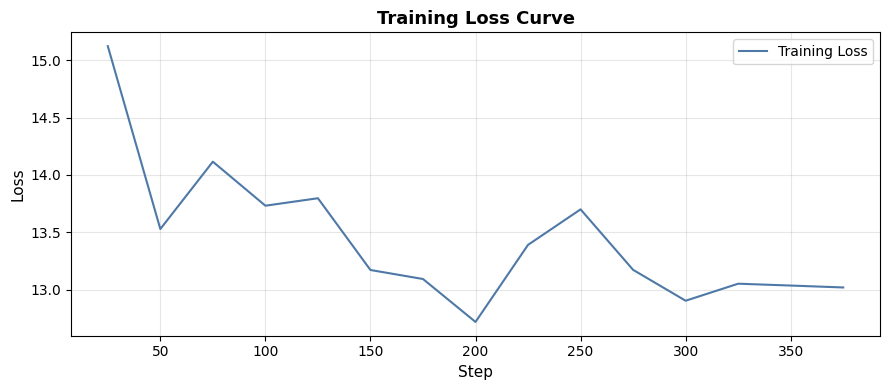


📊 Chart saved as 'training_loss.png'


In [ ]:
# Extract training log
log_history = trainer.state.log_history
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]

if train_logs:
    train_df_log = pd.DataFrame(train_logs)

    plt.figure(figsize=(9, 4))
    plt.plot(train_df_log["step"], train_df_log["loss"],
             color="#4e79a7", linewidth=1.5, label="Training Loss")
    plt.title("Training Loss Curve", fontsize=13, fontweight="bold")
    plt.xlabel("Step", fontsize=11)
    plt.ylabel("Loss", fontsize=11)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("training_loss.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n📊 Chart saved as 'training_loss.png'")
else:
    print("No training logs found.")


### Per-Epoch ROUGE Table


In [ ]:
eval_logs = [x for x in log_history if "eval_rouge1" in x]

if eval_logs:
    eval_df_log = pd.DataFrame(eval_logs)
    rouge_cols = [c for c in ["eval_loss", "eval_rouge1", "eval_rouge2", "eval_rougeL", "eval_rougeLsum"]
                  if c in eval_df_log.columns]
    summary = eval_df_log[rouge_cols].copy()
    summary.columns = [c.replace("eval_", "") for c in rouge_cols]
    summary.index = [f"Epoch {i+1}" for i in range(len(summary))]
    print("Validation ROUGE per Epoch:")
    print("=" * 60)
    print(summary.to_string(float_format="{:.4f}".format))
    print("\n💡 ROUGE should improve each epoch — watch ROUGE-1 and ROUGE-L especially.")
else:
    print("No evaluation logs found.")


Validation ROUGE per Epoch:
          loss  rouge1  rouge2  rougeL  rougeLsum
Epoch 1 1.4024  0.4196  0.1984  0.3034     0.3037
Epoch 2 1.4000  0.4220  0.1996  0.3034     0.3038

💡 ROUGE should improve each epoch — watch ROUGE-1 and ROUGE-L especially.


## 📊 Phase 6: Evaluation

Now the real test: generate summaries for **unseen test articles** and score them with ROUGE.


### Evaluate on Test Set


In [ ]:
print("Evaluating on test set (this runs generation over all 300 test articles)...\n")

test_results = trainer.evaluate(tokenized_datasets["test"])

print("=" * 60)
print("TEST SET RESULTS (ROUGE)")
print("=" * 60)
for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")


Evaluating on test set (this runs generation over all 300 test articles)...



Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum
13.019850,1.482392,2,0.422400,0.194100,0.294400,0.294300


TEST SET RESULTS (ROUGE)
eval_loss: 1.4824
eval_rouge1: 0.4224
eval_rouge2: 0.1941
eval_rougeL: 0.2944
eval_rougeLsum: 0.2943


### Reference vs Model Summaries

Numbers are nice, but for summarization you must **read the output**. Let's compare the model's
generated summaries against the human-written highlights side by side.


In [ ]:
# Generate summaries for 3 test articles
n_show = 3
test_samples = dataset["test"].select(range(n_show))

print(f"Generating summaries for {n_show} test articles...\n")
model.eval()

for i in range(n_show):
    article = test_samples[i]["article"]
    reference = test_samples[i]["highlights"]

    inputs = tokenizer(PREFIX + article, return_tensors="pt",
                       max_length=MAX_SOURCE_LENGTH, truncation=True).to(device)
    with torch.no_grad():
        summary_ids = model.generate(**inputs, max_length=MAX_TARGET_LENGTH, num_beams=4,
                                     length_penalty=2.0, no_repeat_ngram_size=3, early_stopping=True)
    generated = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    print("=" * 80)
    print(f"📄 TEST ARTICLE {i+1} (first 300 chars):")
    print(article[:300] + " ...")
    print(f"\n📖 REFERENCE (human highlights):")
    print(reference)
    print(f"\n🤖 MODEL SUMMARY:")
    print(generated)
    print()

print("=" * 80)
print("\n💡 Ask yourself: is the model summary fluent? Faithful? Concise?")
print("   ROUGE measures overlap, but human judgment is the final metric.")


Generating summaries for 3 test articles...

📄 TEST ARTICLE 1 (first 300 chars):
(CNN) I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. I see it in politicians who once preferred to play it safe with this explosive issue but are now willing to stake their political futures on it. I see the ...

📖 REFERENCE (human highlights):
CNN's Dr. Sanjay Gupta says we should legalize medical marijuana now .
He says he knows how easy it is do nothing "because I did nothing for too long"

🤖 MODEL SUMMARY:
A majority, 53%, favor its legalization, with 77% supporting it for medical purposes . Support for legalization has risen 11 points in the past few years alone . The revolution is burning white hot among young people, but also shows up among the parents and grandparents in my kids' school .

📄 TEST ARTICLE 2 (first 300 chars):
He looks barely teenage. But this child has amassed thousands of Twitter followers 

## 🎯 Phase 7: Inference (Generating Summaries)

In the earlier notebooks, inference meant running a **classifier**: one forward pass, read the logits.

For seq2seq models, inference means **generation**: the decoder produces tokens **one at a time,
autoregressively**, feeding each new token back as input until it emits `<eos>`. That's what
`model.generate()` does — with search strategies like **beam search** to explore multiple
candidate continuations and pick the best.


### Define summarize() Helper


In [ ]:
def summarize(text, model, tokenizer, device, max_length=MAX_TARGET_LENGTH):
    """
    Generate an abstractive summary of an input text with FLAN-T5.

    Args:
        text:      Input article string
        model:     Trained seq2seq model
        tokenizer: T5 tokenizer
        device:    Torch device (cuda / mps / cpu)
        max_length: Maximum summary length in tokens

    Generation settings:
        num_beams=4          — beam search: keep 4 candidate beams, pick the best
        length_penalty=2.0   — reward longer, more complete summaries
        no_repeat_ngram_size=3 — forbid repeating any 3-gram (kills loops)
        early_stopping=True  — stop all beams once they hit EOS
    """
    inputs = tokenizer(PREFIX + text, return_tensors="pt",
                       max_length=MAX_SOURCE_LENGTH, truncation=True).to(device)

    model.eval()
    with torch.no_grad():
        summary_ids = model.generate(
            **inputs,
            num_beams=4,
            max_length=max_length,
            length_penalty=2.0,
            no_repeat_ngram_size=3,
            early_stopping=True
        )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("✅ summarize() function defined!")


✅ summarize() function defined!


### Test on a Custom Article


In [ ]:
# A short news paragraph written just for this test — NOT from the dataset!
custom_article = """
Local officials announced on Tuesday that the city's aging public library will undergo a
$12 million renovation beginning next spring. The project, funded by a combination of
municipal bonds and private donations, will add a new children's wing, expand digital
learning labs, and restore the building's historic reading room. Construction is expected
to take 18 months, during which the library will operate from a temporary location in the
community center. Mayor Sandra Ellis called the library "the heart of our downtown" and
said the renovation would preserve its character while bringing it into the 21st century.
A public groundbreaking ceremony is scheduled for April.
"""

print("📝 Custom article:")
print(custom_article.strip())
print("\n🤖 Model summary:")
print(summarize(custom_article, model, tokenizer, device))


📝 Custom article:
Local officials announced on Tuesday that the city's aging public library will undergo a
$12 million renovation beginning next spring. The project, funded by a combination of
municipal bonds and private donations, will add a new children's wing, expand digital
learning labs, and restore the building's historic reading room. Construction is expected
to take 18 months, during which the library will operate from a temporary location in the
community center. Mayor Sandra Ellis called the library "the heart of our downtown" and
said the renovation would preserve its character while bringing it into the 21st century.
A public groundbreaking ceremony is scheduled for April.

🤖 Model summary:
The city's aging public library will undergo a $12 million renovation . Construction is expected to take 18 months, during which the library will operate from a temporary location . Mayor Sandra Ellis called the library "the heart of our downtown"


### ⚠️ transformers 5.x Note: The `summarization` Pipeline Is Gone

Earlier transformers versions had a one-liner `pipeline("summarization", ...)`.
**transformers 5.x removed the seq2seq pipeline tasks** (no `summarization`,
no `text2text-generation`) — generation now goes through `model.generate()` directly.
The good news: our `summarize()` helper already wraps tokenization + beam search,
so batching over several texts stays a one-liner:


In [ ]:
# Batch summarization with the helper (the modern replacement for the old pipeline)
texts = [
    "Scientists at the university have developed a new battery material that could "
    "double the range of electric vehicles while cutting charging time in half, "
    "according to a study published this week.",
    "The city council voted on Tuesday to expand the metro network with three new "
    "lines, a project expected to create thousands of jobs over the next decade.",
]

for text in texts:
    print(f"Text:    \"{text}\"")
    print(f"Summary: {summarize(text, model, tokenizer, device)}")
    print("-" * 80)


Text:    "Scientists at the university have developed a new battery material that could double the range of electric vehicles while cutting charging time in half, according to a study published this week."
Summary: Scientists at the university have developed a new battery material . The material could double the range of electric vehicles while cutting charging time in half .
--------------------------------------------------------------------------------
Text:    "The city council voted on Tuesday to expand the metro network with three new lines, a project expected to create thousands of jobs over the next decade."
Summary: The city council voted on Tuesday to expand the metro network with three new lines . The project is expected to create thousands of jobs over the next decade .
--------------------------------------------------------------------------------


## 💾 Phase 8: Save, Load and Push to Hub


### Save Model to Disk


In [ ]:
save_directory = "./flan-t5-summarizer"

trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"✅ Model saved to: {save_directory}")
print(f"   Saved files: {sorted(os.listdir(save_directory))}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to: ./flan-t5-summarizer
   Saved files: ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


### Load Model from Disk and Verify


In [ ]:
print("Testing model loading from disk...\n")

loaded_tokenizer = AutoTokenizer.from_pretrained(save_directory)
loaded_model     = AutoModelForSeq2SeqLM.from_pretrained(save_directory)
loaded_model.to(device)

# Quick sanity check with the same helper as Phase 7
verify_text = ("The national team won the championship on Sunday after a dramatic final, "
               "beating their rivals 2-1 in extra time before a sold-out stadium.")
print("📝 Verify article:")
print(f"   {verify_text}")
print("\n🤖 Summary from reloaded model:")
print(summarize(verify_text, loaded_model, loaded_tokenizer, device))
print("\n✅ Model loaded from disk and generating summaries correctly!")


Testing model loading from disk...



Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


📝 Verify article:
   The national team won the championship on Sunday after a dramatic final, beating their rivals 2-1 in extra time before a sold-out stadium.

🤖 Summary from reloaded model:
The national team won the championship on Sunday after a dramatic final . They beat their rivals 2-1 in extra time before a sold-out stadium .

✅ Model loaded from disk and generating summaries correctly!


### (Optional) Push to Hugging Face Hub

You can share your fine-tuned model with the world by pushing it to Hugging Face Hub.

> You'll need a free account at [huggingface.co](https://huggingface.co) and an access token.


In [ ]:
PUSH_TO_HUB = True  # <-- set True to push your fine-tuned model to Hugging Face Hub

if PUSH_TO_HUB:
    from huggingface_hub import login
    login()  # Enter your HF token when prompted
else:
    print("Skipping HF login (set PUSH_TO_HUB = True to enable)")



In [ ]:
# Push your model to the Hub (set PUSH_TO_HUB = True above to enable)
YOUR_USERNAME = "msaifee"  # <-- change this

if PUSH_TO_HUB:
    trainer.push_to_hub(f"{YOUR_USERNAME}/flan-t5-summarizer")
    tokenizer.push_to_hub(f"{YOUR_USERNAME}/flan-t5-summarizer")

    print("💡 Your model is now publicly available at:")
    print(f"   https://huggingface.co/{YOUR_USERNAME}/flan-t5-summarizer")
else:
    print("Skipping push to Hub (set PUSH_TO_HUB = True to enable)")



## 📝 Summary


In [ ]:
print("\n" + "=" * 70)
print("TRAINING SUMMARY")
print("=" * 70)

rouge1  = test_results.get("eval_rouge1",  0)
rouge2  = test_results.get("eval_rouge2",  0)
rougeL  = test_results.get("eval_rougeL",  0)
rougeLs = test_results.get("eval_rougeLsum", 0)

print(f"""
Model Configuration:
  - Base Model:  {MODEL_NAME}  (~{total_params/1e6:.0f}M parameters)
  - Task:        Abstractive text summarization
  - Vocab size:  {model.config.vocab_size:,}
  - Task prefix: \"{PREFIX}\"

Dataset:
  - Dataset:     CNN/DailyMail {DATASET_CONFIG} (parquet export)
  - Sizes:       {TRAIN_SIZE} train / {VAL_SIZE} val / {TEST_SIZE} test
  - Source len:  ≤ {MAX_SOURCE_LENGTH} tokens   Target len: ≤ {MAX_TARGET_LENGTH} tokens

Performance (Test Set):
  - ROUGE-1:    {rouge1:.4f}
  - ROUGE-2:    {rouge2:.4f}
  - ROUGE-L:    {rougeL:.4f}
  - ROUGE-Lsum: {rougeLs:.4f}

Training Setup:
  - Epochs:           {NUM_EPOCHS}
  - Batch size:       {BATCH_SIZE} × {GRADIENT_ACCUMULATION_STEPS} grad accum = {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS} effective
  - LR:               {LEARNING_RATE}
  - Optimizer:        {OPTIMIZER}
  - Total steps:      {total_steps}

Seq2Seq-Specific Pieces:
  - DataCollatorForSeq2Seq (dynamic padding, label_pad_token_id=-100)
  - Seq2SeqTrainer with predict_with_generate=True
  - ROUGE metric with sentence-split post-processing
  - Beam search (num_beams=4, length_penalty=2.0) at inference

Files Generated:
  - ./flan-t5-summarizer/   (saved model + tokenizer)
  - training_loss.png
""")

print("=" * 70)
print("🎉 CONGRATULATIONS! You've successfully fine-tuned FLAN-T5 for summarization!")
print("=" * 70)



TRAINING SUMMARY

Model Configuration:
  - Base Model:  google/flan-t5-large  (~783M parameters)
  - Task:        Abstractive text summarization
  - Vocab size:  32,128
  - Task prefix: "summarize: "

Dataset:
  - Dataset:     CNN/DailyMail 3.0.0 (parquet export)
  - Sizes:       3000 train / 400 val / 300 test
  - Source len:  ≤ 512 tokens   Target len: ≤ 128 tokens

Performance (Test Set):
  - ROUGE-1:    0.4224
  - ROUGE-2:    0.1941
  - ROUGE-L:    0.2944
  - ROUGE-Lsum: 0.2943

Training Setup:
  - Epochs:           2
  - Batch size:       2 × 8 grad accum = 16 effective
  - LR:               2e-05
  - Optimizer:        adamw_torch_fused
  - Total steps:      376

Seq2Seq-Specific Pieces:
  - DataCollatorForSeq2Seq (dynamic padding, label_pad_token_id=-100)
  - Seq2SeqTrainer with predict_with_generate=True
  - ROUGE metric with sentence-split post-processing
  - Beam search (num_beams=4, length_penalty=2.0) at inference

Files Generated:
  - ./flan-t5-summarizer/   (saved model +

## 🚀 Next Steps

1. **Try `flan-t5-base` vs `flan-t5-large`**: swap `MODEL_NAME` and compare ROUGE scores vs training time — a great lesson in the size/quality trade-off.

2. **Train on the full CNN/DailyMail**: sub-sample 10K–50K examples (or the full 287K) for a serious ROUGE boost.

3. **Other summarization datasets**: try `xsum` (one-sentence extreme summaries) or `samsum` (chat-dialogue summaries — note: **gated**, you must accept the terms on the dataset page before it loads).

4. **Parameter-Efficient Fine-Tuning (PEFT/LoRA)**: freeze the base model and train tiny adapter layers — trains faster with a fraction of the memory.

5. **Reuse the same model for translation**: FLAN-T5 does many tasks — just change the prefix to `"translate English to German: "` and fine-tune on a parallel corpus!

---
**Happy Fine-Tuning! 🎯**


## 🔄 BERT vs GPT vs T5 — Final Comparison

After completing all three notebooks, here's the complete picture:

| Comparison Point | BERT Notebook | GPT Notebook | T5 Notebook (this one) |
|-----------------|---------------|--------------|------------------------|
| **Model** | `distilbert-base-uncased` | `distilgpt2` | `google/flan-t5-large` |
| **Architecture** | Encoder (bidirectional) | Decoder (causal) | **Encoder + Decoder** |
| **Parameters** | ~66M | ~82M | ~780M |
| **Task in this course** | Tweet sentiment (3 classes) | News topic (4 classes) | **Summarization (free text!)** |
| **Tokenizer quirks** | None | No pad token → borrow `eos`; left-padding | **None — native `<pad>`, but needs `"summarize: "` prefix** |
| **Training class** | `Trainer` | `Trainer` | **`Seq2SeqTrainer`** |
| **Metrics** | Accuracy / F1 | Accuracy / F1 | **ROUGE-1/2/L** |
| **Inference** | One forward pass → logits | One forward pass → logits | **Autoregressive `generate()` → text** |

### 💡 Key Takeaway

> **Encoder-only** models (BERT) excel at *understanding*; **decoder-only** models (GPT) excel at
> *generation*; **encoder-decoder** models (T5, BART) combine both — the encoder reads the input,
> the decoder writes the output — making them the classic choice for **sequence-to-sequence** tasks
> like summarization and translation. You now know how to fine-tune all three!
